In [ ]:
!pip install seaborn



=== Dataset: Blobs (Linear) ===

Kernel: linear
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       150
           1      1.000     1.000     1.000       150

    accuracy                          1.000       300
   macro avg      1.000     1.000     1.000       300
weighted avg      1.000     1.000     1.000       300



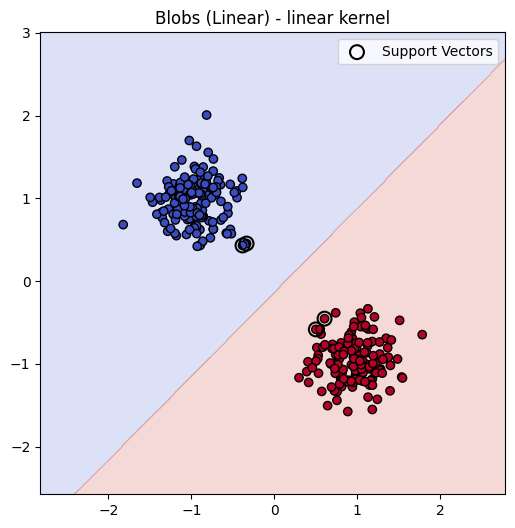


Kernel: poly
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       150
           1      1.000     1.000     1.000       150

    accuracy                          1.000       300
   macro avg      1.000     1.000     1.000       300
weighted avg      1.000     1.000     1.000       300



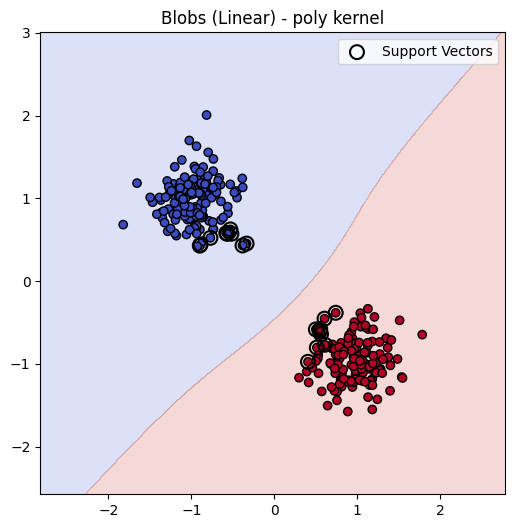


Kernel: rbf
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       150
           1      1.000     1.000     1.000       150

    accuracy                          1.000       300
   macro avg      1.000     1.000     1.000       300
weighted avg      1.000     1.000     1.000       300



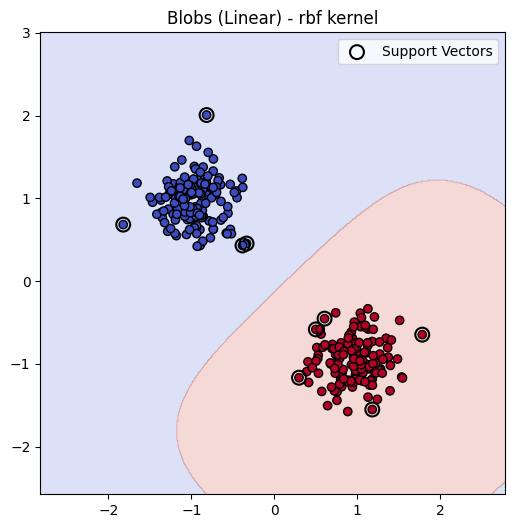


=== Dataset: Moons (Non-linear) ===

Kernel: linear
              precision    recall  f1-score   support

           0      0.864     0.887     0.875       150
           1      0.884     0.860     0.872       150

    accuracy                          0.873       300
   macro avg      0.874     0.873     0.873       300
weighted avg      0.874     0.873     0.873       300



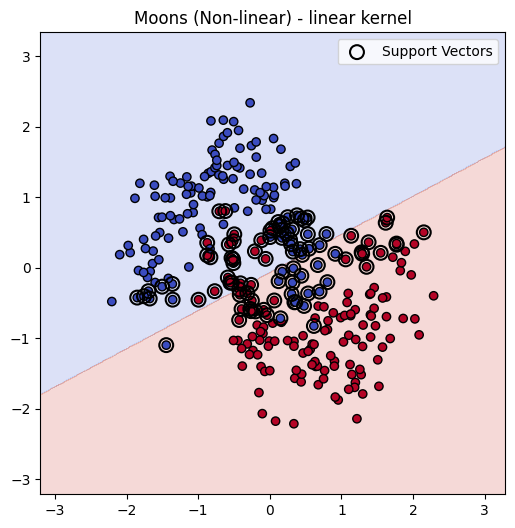


Kernel: poly
              precision    recall  f1-score   support

           0      0.848     0.927     0.885       150
           1      0.919     0.833     0.874       150

    accuracy                          0.880       300
   macro avg      0.883     0.880     0.880       300
weighted avg      0.883     0.880     0.880       300



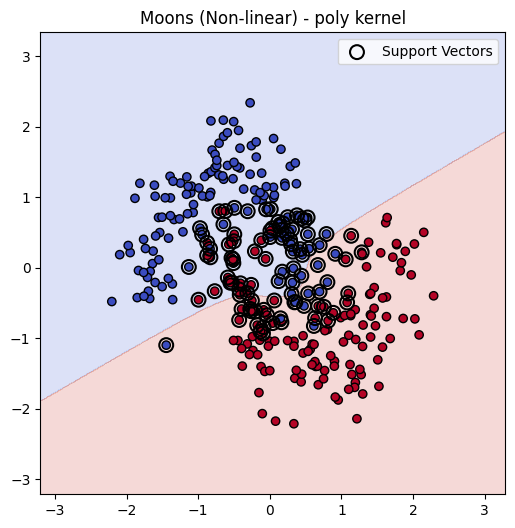


Kernel: rbf
              precision    recall  f1-score   support

           0      0.946     0.933     0.940       150
           1      0.934     0.947     0.940       150

    accuracy                          0.940       300
   macro avg      0.940     0.940     0.940       300
weighted avg      0.940     0.940     0.940       300



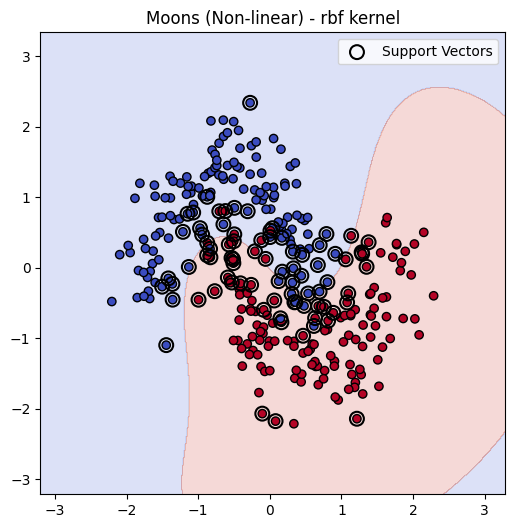


=== Dataset: Circles (Non-linear) ===

Kernel: linear
              precision    recall  f1-score   support

           0      0.550     0.440     0.489       150
           1      0.533     0.640     0.582       150

    accuracy                          0.540       300
   macro avg      0.542     0.540     0.535       300
weighted avg      0.542     0.540     0.535       300



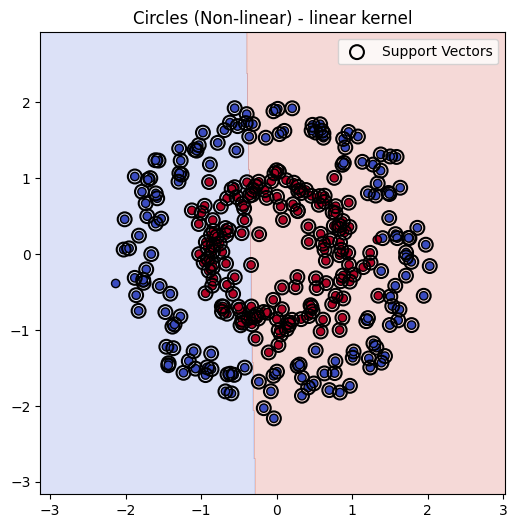


Kernel: poly
              precision    recall  f1-score   support

           0      1.000     0.380     0.551       150
           1      0.617     1.000     0.763       150

    accuracy                          0.690       300
   macro avg      0.809     0.690     0.657       300
weighted avg      0.809     0.690     0.657       300



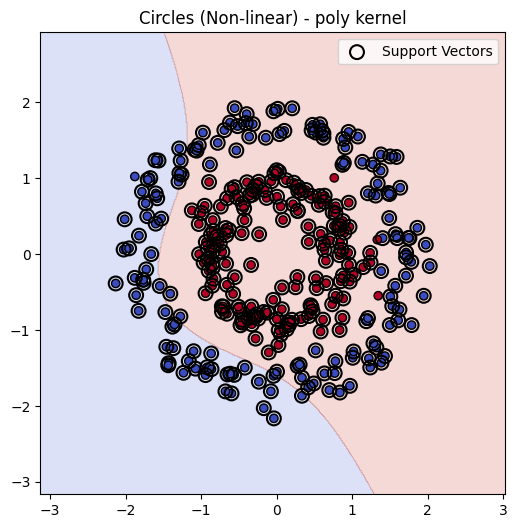


Kernel: rbf
              precision    recall  f1-score   support

           0      0.980     1.000     0.990       150
           1      1.000     0.980     0.990       150

    accuracy                          0.990       300
   macro avg      0.990     0.990     0.990       300
weighted avg      0.990     0.990     0.990       300



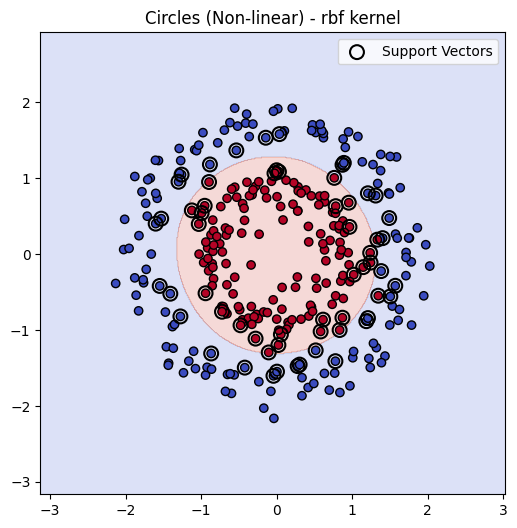


=== Dataset: Classification (Custom) ===

Kernel: linear
              precision    recall  f1-score   support

           0      0.915     0.933     0.924       150
           1      0.932     0.913     0.923       150

    accuracy                          0.923       300
   macro avg      0.924     0.923     0.923       300
weighted avg      0.924     0.923     0.923       300



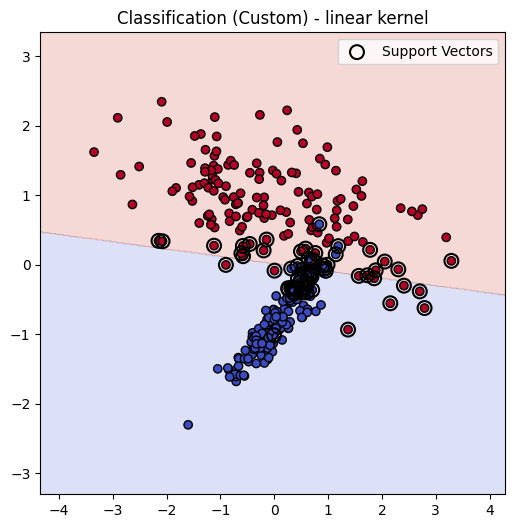


Kernel: poly
              precision    recall  f1-score   support

           0      0.860     0.980     0.916       150
           1      0.977     0.840     0.903       150

    accuracy                          0.910       300
   macro avg      0.918     0.910     0.910       300
weighted avg      0.918     0.910     0.910       300



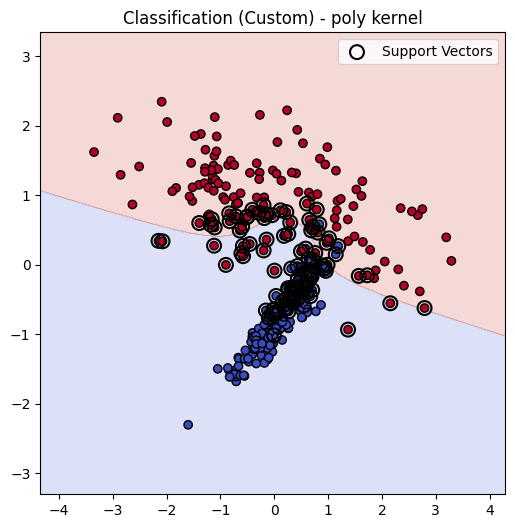


Kernel: rbf
              precision    recall  f1-score   support

           0      0.948     0.980     0.964       150
           1      0.979     0.947     0.963       150

    accuracy                          0.963       300
   macro avg      0.964     0.963     0.963       300
weighted avg      0.964     0.963     0.963       300



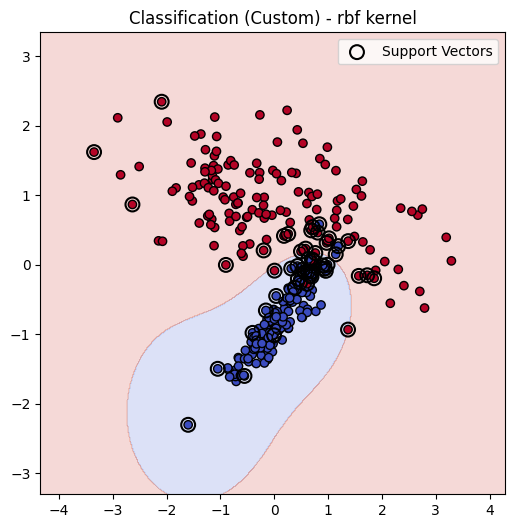

In [ ]:
!pip install seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
    plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
                s=100, facecolors='none', edgecolors='k', linewidths=1.5,
                label="Support Vectors")
    plt.title(title)
    plt.legend()
    plt.show()

datasets = {
    "Blobs (Linear)": make_blobs(n_samples=300, centers=2, random_state=42, cluster_std=1.0),
    "Moons (Non-linear)": make_moons(n_samples=300, noise=0.2, random_state=42),
    "Circles (Non-linear)": make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42),
    "Classification (Custom)": make_classification(n_samples=300, n_features=2,
                                                   n_informative=2, n_redundant=0,
                                                   n_clusters_per_class=1,
                                                   random_state=42)
}


kernels = ['linear', 'poly', 'rbf']

for name, (X, y) in datasets.items():
    print(f"\n=== Dataset: {name} ===")

    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    for kernel in kernels:
        clf = SVC(kernel=kernel, gamma='scale', C=1)
        clf.fit(X, y)

        # Evaluation
        y_pred = clf.predict(X)
        print(f"\nKernel: {kernel}")
        print(classification_report(y, y_pred, digits=3))

        # Plot boundary
        plot_decision_boundary(clf, X, y, f"{name} - {kernel} kernel")


